### 1D code CMI simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import math

Defining the code size and partitions into subregions 

In [11]:
#Total number of qubits 
N = 25 
#Size of middle region 
R = 5

#Subregion sizes
A = 5
B = 2*R 
C = N - A - B 

We calcualte CMI as:

\begin{equation}

CMI = I(A:C|B) = H(AB) + H(BC) - H(ABC) - H(B),

\end{equation}

where $H(Q)$ is the Shannon entropy of the $Q$ subregion:

\begin{equation}

H(Q) = \sum_{s} Pr(s) \cdot log_2 Pr(s), 

\end{equation}


\begin{equation}

Pr(s) = p^{|s|}(p-1)^{N-|s|},

\end{equation}

where $p$ is the noise rate (probability of a physical qubit to flip), $s \in \{0,1\}^N$ is the vector of syndormes (list of flip - entry 1, or no flip - entry 0) for each physical qubit, and N is the total number of qubits. For subregion Q, we only consider the substring (part of the vector) corresponding to qubits in Q.



Generating all possible strings of 0's and 1's of length N. We need to sum over them to calculate CMI.

In [12]:
strings = list(product([0, 1], repeat=N))

strings = np.array(strings)

print(strings)
print(strings.shape)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]
 ...
 [1 1 1 ... 1 0 1]
 [1 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 1]]
(33554432, 25)


We generated an array of 1024 rows (all strings) and 10 columns (N= 10 is the number of physical qubits)

In [9]:


def H_ABC(p,strings,N):
    """ 
    Function to compute H(ABC) for noise rate p and the list of strings
    """
    number_rows = len(strings)
    H_ABC = 0
    for s in range(number_rows):
        len_s = sum(strings[s])
        Pr = p**len_s * (1-p)**(N - len_s)/number_rows
        H = -1* Pr* math.log2(Pr)
        H_ABC += H
    return H_ABC

def H_B(p,strings,N,A,R):
    """ 
    Function to compute H(B) for noise rate p and the list of strings
    """
    number_rows = len(strings)
    H_B = 0
    for s in range(number_rows):
        new_string = np.hstack((strings[s,A:A+R],strings[s,N-R:N]))
        len_s = sum(new_string)
        Pr = p**len_s * (1-p)**(2*R - len_s)/number_rows
        H = -1* Pr* math.log2(Pr)
        H_B += H
    return H_B

def H_AB(p,strings,N,A,R):
    """ 
    Function to compute H(AB) for noise rate p and the list of strings
    """
    number_rows = len(strings)
    H_AB = 0
    for s in range(number_rows):
        new_string = np.hstack((strings[s,0:A+R],strings[s,N-R:N]))
        len_s = sum(new_string)
        Pr = p**len_s * (1-p)**(A+2*R - len_s)/number_rows
        H = -1* Pr* math.log2(Pr)
        H_AB += H
    return H_AB

def H_BC(p,strings,N,A):
    """ 
    Function to compute H(BC) for noise rate p and the list of strings
    """
    number_rows = len(strings)
    H_AB = 0
    for s in range(number_rows):
        new_string = strings[s,A:N]
        len_s = sum(new_string)
        Pr = p**len_s * (1-p)**(N-A - len_s)/number_rows
        H = -1* Pr* math.log2(Pr)
        H_AB += H
    return H_AB

In [13]:
#Test

print(H_ABC(0.05,strings,N))

print(H_B(0.05,strings,N,A,R))

print(H_AB(0.05,strings,N,A,R))

print(H_BC(0.05,strings,N,A))

9.584404206215353e-07
0.0272109077854132
0.0008940415759420501
2.9304446347261766e-05


Comment: the code runs for a very long time: Taking a few minutes per term

In [6]:
#Test 

s=240
print(strings[s,A:A+R])
print(strings[s,N-R:N])
new_string = np.hstack((strings[s,A:A+R],strings[s,N-R:N]))
print(new_string)

[0 0 0 0 0]
[1 0 0 0 0]
[0 0 0 0 0 1 0 0 0 0]


In [14]:
#Array of different probability values

noise_rates = np.linspace(0.01,0.99,10)
CMI = np.zeros(len(noise_rates))

for k in range(len(noise_rates)):
    p = noise_rates[k]
    cmi = H_AB(p,strings,N,A,R) + H_BC(p,strings,N,A) - H_B(p,strings,N,A,R) - H_ABC(p,strings,N)
    CMI[k] = cmi

Plot

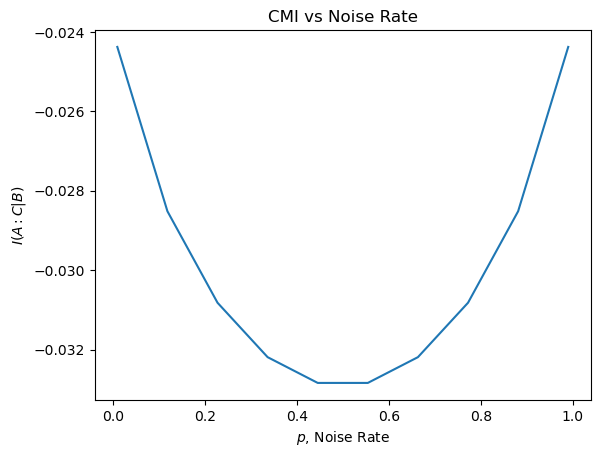

In [15]:
fig, ax = plt.subplots()

ax.plot(noise_rates , CMI)
ax.set_title("CMI vs Noise Rate")
ax.set_xlabel("$p$, Noise Rate")
ax.set_ylabel("$I(A:C|B)$")

plt.show()

Slower system but more noise rates

In [16]:
#Total number of qubits 
N1 = 12
#Size of middle region 
R1 = 2

#Subregion sizes
A1 = 4
B1 = 2*R1 
C1 = N1- A1 - B1 

In [18]:
strings1 = list(product([0, 1], repeat=N1))

strings1 = np.array(strings1)

print(strings1)
print(strings1.shape)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]
 ...
 [1 1 1 ... 1 0 1]
 [1 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 1]]
(4096, 12)


In [19]:
print(H_ABC(0.5,strings1,N1))

print(H_B(0.5,strings1,N1,A1,R1))

print(H_AB(0.5,strings1,N1,A1,R1))

print(H_BC(0.5,strings1,N1,A1))

0.005859375
1.0
0.078125
0.078125


In [27]:
#Array of different probability values

noise_rates1 = np.linspace(0.0001,0.9999,30)
CMI1 = np.zeros(len(noise_rates1))

for k in range(len(noise_rates1)):
    p = noise_rates1[k]
    cmi1 = H_AB(p,strings1,N1,A1,R1) + H_BC(p,strings1,N1,A1) - H_B(p,strings1,N1,A1,R1) - H_ABC(p,strings1,N1)
    print(cmi1)
    CMI1[k] = cmi1

-0.659460196814482
-0.7004732847604147
-0.7281866198903506
-0.750600993685619
-0.7694358190173257
-0.7855002849912681
-0.7992639947799547
-0.8110305962999199
-0.8210094151603237
-0.829350473366673
-0.8361635843418238
-0.841529563667071
-0.8455071371833683
-0.8481373034910942
-0.8494460714853036
-0.8494460714853025
-0.8481373034910962
-0.8455071371833695
-0.8415295636670707
-0.8361635843418235
-0.8293504733666744
-0.821009415160324
-0.8110305962999228
-0.7992639947799617
-0.785500284991267
-0.7694358190173306
-0.7506009936856168
-0.728186619890351
-0.7004732847604097
-0.6594601968144833


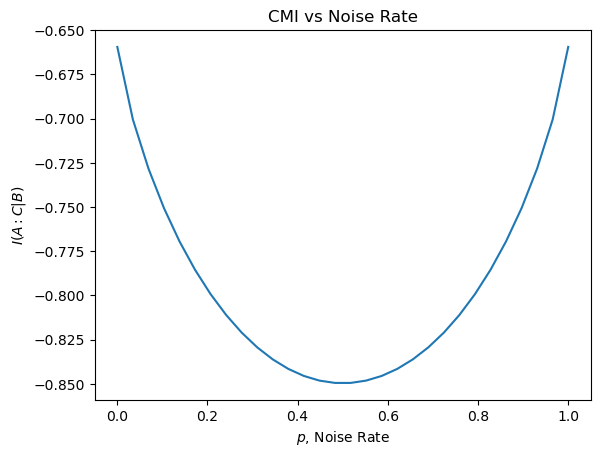

In [29]:
fig, ax = plt.subplots()

ax.plot(noise_rates1 , CMI1)
#ax.plot(noise_rates , CMI)
ax.set_title("CMI vs Noise Rate")
ax.set_xlabel("$p$, Noise Rate")
ax.set_ylabel("$I(A:C|B)$")

plt.show()